In [1]:

import os
# Make sure you are in scMEDAL_for_scRNAseq dir
os.chdir("/archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq")

from models.models import train_model_on_named_experiment

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [ ]:

os.getcwd()

## Training Models:

#### Implemented Models:
| Model Class | Model Description | 
|------------|--------------------|  
| `AE` | Autoencoder | 
| `AEC`| Autoencoder Classifier |
| `scMEDAL-FE` | Domain Adversarial Autoencoder |
| `scMEDAL-FEC`| Domain Adversarial Autoencoder Classifier |
| `scMEDAL-RE`| Domain Enhancing Autoencoder Classifier | 

#### Named Experiments:
| Valid Named Experiment | Dataset |  n_clusters | n_pred |
|------------------------|---------|-------------|--------|
| `AML`| Acute Myeloid Leukemia | 19 | 21 |
| `ASD`| Autism Spectrum Disorder | 31 | 17 | 
| `HH` | Healthy Heart | 147 | 13 | 

**Note:** If training on other datasets, the configs will need to be passed in as dictionaries to `model_kwargs` and `train_kwargs`.

`quick` is a boolean flag that can be passed to `train_kwargs` which shortens training to only 1 fold for 3 epochs.

In [ ]:
# Run "scmedalfe" and "scmedalre" models
scmedalfe_aml= train_model_on_named_experiment("scMEDAL-FE", "AML", model_kwargs={"n_latent_dims":50},train_kwargs={"quick":True}) #train_kwargs={"epochs": 2,"fold_list":[1,2]})
scmedalre_aml = train_model_on_named_experiment("scMEDAL-RE", "AML", model_kwargs={"n_latent_dims":50}, train_kwargs={"quick":True})

## Analyzing Models:

When you run a model, it generates the following output directories:
   - /outputs/figures
   - /outputs/latent_space
   - /outputs/saved_models
 
 Inside each of these directories, there is a subdirectory named after the model and its run identifier.
 
 For example: $AML/latent\_space/scmedalfe/run\_crossval\_<run\_name>$

 To analyze your results, copy the corresponding $<run\_name>$ below.

In [2]:

# When you run your model, it outputs the figures, latent_space and saved_models directories, whitin those directories you will find a subdir with the name of the model trained, example: AML/latent_space/scmedalfe/run_crossval_<run_name>
#Please copy the <run_name below> to analyze the results
# Update output paths of the models that you just run
from utils.defaults import AML_OUTPUTS_DIR
print(f"Loading outputs from {AML_OUTPUTS_DIR}. Please verify that your models output folder is located here before proceeding with the analysis.")

import os
model_folder_dict = {
    #"ae":"",
    #"ae":"",
    #"aec":"",
    "scmedalfe":"run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-50_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-08_11-59",
    #"scmedalfec":"",
    "scmedalre":"run_crossval_loss_recon_weight-110.0_loss_latent_cluster_weight-0.1_n_latent_dims-50_layer_units-512-132_kl_weight-0.0_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-08_11-59",
}
model_paths = {k:os.path.join(AML_OUTPUTS_DIR, "latent_space", "log_transformed_2916hvggenes",k, v) for k, v in model_folder_dict.items()}


Loading outputs from /endosome/archive/bioinformatics/DLLab/src/AixaAndrade/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/AML. Please verify that your models output folder is located here before proceeding with the analysis.


##### Step 1: Import the analysis class and initialize it

In [4]:

import analysis.analysis as aa

analysis_name = "AML_default"



aml = aa.AMLAnalysis(model_folder_dict, analysis_name)

##### Step 2: Compile clustering scores calculated after training the models

In [3]:


res= aml.clustering_scores(model_folder_dict)
# You can now inspect or export `clustering_results` as needed
# Note: if you only run 1 fold, you will see NAN in CI entries
res

Directory created or already exists: /endosome/archive/bioinformatics/DLLab/src/AixaAndrade/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/AML/compare_models/log_transformed_2916hvggenes/AML_default

Computed aggregated scores DataFrame
Computed Confidence interval results for sample size: 10000, saved to: /endosome/archive/bioinformatics/DLLab/src/AixaAndrade/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/AML/compare_models/log_transformed_2916hvggenes/AML_default
 


batch                                                          \
              1/db                         ch                   silhouette   
              mean CI_lower CI_upper     mean CI_lower CI_upper       mean   
dataset_type                                                                 
scmedalfe      0.1      NaN      NaN   126.04      NaN      NaN      -0.19   
scmedalre      0.6      NaN      NaN  2026.11      NaN      NaN       0.44   

                               celltype                                      \
                                   1/db                         ch            
             CI_lower CI_upper     mean CI_lower CI_upper     mean CI_lower   
dataset_type                                                                  
scmedalfe         NaN      NaN     0.17      NaN      NaN  1128.00      NaN   
scmedalre         NaN      NaN     0.19      NaN      NaN   192.42      NaN   

                                                    
                      silhouette                    
             CI_upper       mean CI_lower CI_upper  
dataset_type                                        
scmedalfe         NaN      -0.02      NaN      NaN  
scmedalre         NaN      -0.05      NaN      NaN

##### Step 3: Generate and save the UMAP plots

In [ ]:

# This typically loads latent representations stored after training and creates UMAPs for each model
processors = aml.umap(model_folder_dict, types=["train"], splits=[1])
processors

##### Step 4: Run genomaps on a subsample of the input data along with reconstructions from the scmedalfe and scmedalre models. 

Visualize selected batches to assess batch-specific effects in the reconstructed spaces, including conterfactual projections from scmedalre.

In [ ]:
# 

batches = ["AML420B", "BM5", "MUTZ3"]
celltype = ["Mono", "Mono-like"]
# for this genomap config, you need to compute first the reconstructions from scMEDAL-FE and scMEDAL-RE
selected_models = {k: model_folder_dict[k] for k in ("scmedalfe", "scmedalre")}
gfd = aml.genomap(selected_models,
                            n_batches = 19,
                            num_iter = 2, # for quick test, otherwise 100
                            cell_id_col = "Cell",
                            gene_index_col = "Gene",
                            celltype = ["Mono", "Mono-like"],
                            batches=batches,
                            models=['scmedalre'],#if add_inputs_fe=True-> scmedalfe+ inputs are used for genomap creation by default, no need to add the to the list, 
                            types=["train"], 
                            splits=[1],
                            add_inputs_fe= True,
                            extra_recon = "fe",
                            min_val = -1,
                            max_val =2)

## Run the Mixed Effects Classifier (MEC) on latent spaces generated by scmedalfe and scmedalre.
You can specify different classification targets:

    - 21 individual cell types
    
    - 3 patient groups (e.g., AML vs. Normal)

In [ ]:
# Run MEC on scmedalfe + scmedalre, target: 21 celltypes 
mec_aml = train_model_on_named_experiment("MEC", "AML", 
                                    train_kwargs={"quick":True, "results_path_dict":model_paths, },
                                    model_kwargs={"n_pred":21,
                                                   "bio_col_categories":"celltype",
                                                   "models_list":list(model_paths.keys()),
                                                   "latent_keys_config":{"fe_latent":"scmedalfe_latent", "re_latent":"scmedalre_latent"}})

                                                # "get_pca":True,
                                                #"latent_keys_config":{"fe_latent":"X_pca", "re_latent":"re_latent"}}

Training on named_experiment: AML
Parent folder: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/AML_data/log_transformed_2916hvggenes/splits
Save model set to: True
Loading model params.bio_col:celltype (target) and calculating model params.n_pred:21 (predictions), please check if this is your desired config
Number of batches: 19
Ordered batches (params.batch_col_categories): ['AML1012', 'AML210A', 'AML328', 'AML329', 'AML419A', 'AML420B', 'AML475', 'AML556', 'AML707B', 'AML870', 'AML916', 'AML921A', 'BM1', 'BM2', 'BM3', 'BM4', 'BM5', 'MUTZ3', 'OCI']
Ordered target classes (bio_col_categories): ['B', 'CTL', 'GMP', 'GMP-like', 'HSC', 'HSC-like', 'Mono', 'Mono-like', 'NK', 'Plasma', 'ProB', 'ProMono', 'ProMono-like', 'Prog', 'Prog-like', 'T', 'cDC', 'cDC-like', 'earlyEry', 'lateEry', 'pDC']
n target classes len(bio_col_categories): 21
{'scmedalfe': '/endosome/archive/bioinformatics/DLLab/src/AixaAndrade/gitfront/dev2/scMEDAL_for_scRNAseq/outp

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationW

X.shape before scaling (7684, 2916)
Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/AML_data/log_transformed_2916hvggenes/splits/split_1/test
X.shape before scaling (7684, 2916)


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)



adata_dict structure
train
val
test
train_y
train_z
val_y
val_z
test_y
test_z
None
Batches available:  ['AML1012' 'AML210A' 'AML328' 'AML329' 'AML419A' 'AML420B' 'AML475'
 'AML556' 'AML707B' 'AML870' 'AML916' 'AML921A' 'BM1' 'BM2' 'BM3' 'BM4'
 'BM5' 'MUTZ3' 'OCI']

inputs: {'train': {'fe_latent': array([[ 3.09962809e-01,  5.60228825e-01, -2.74819642e-01, ...,
         4.38918859e-01,  5.14497161e-01, -5.00247478e-01],
       [ 5.25441281e-02,  1.13071851e-03, -5.79727173e-01, ...,
         2.73911774e-01, -2.59438138e-02,  2.93128371e-01],
       [ 4.59941179e-01,  1.43942058e-01, -7.96962023e-01, ...,
         3.13328564e-01,  2.57452428e-01, -2.32897326e-01],
       ...,
       [ 5.27057827e-01,  7.33096421e-01, -4.69101518e-01, ...,
         2.79822379e-01,  2.33228445e-01, -7.34834850e-01],
       [-1.04433942e+00, -8.03986490e-01,  3.84705067e-01, ...,
        -3.64926815e-01, -8.45634997e-01,  1.00647405e-01],
       [-1.37258029e+00, -1.12431037e+00,  3.70384365e-01, ...,
     

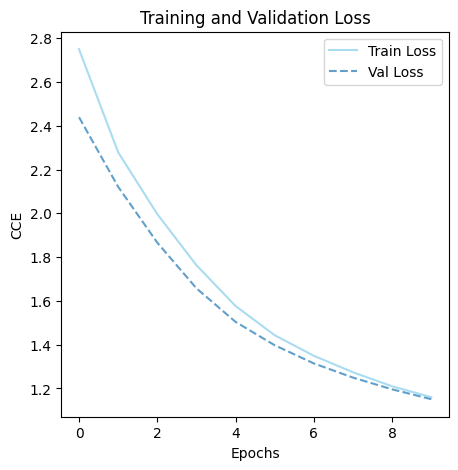

In [4]:
# Run MEC on scmedalfe + scmedalre, target: 3 Patient_group
mec_aml = train_model_on_named_experiment("MEC", "AML", 
                                    train_kwargs={"quick":True, "results_path_dict":model_paths, },
                                    model_kwargs={"n_pred":3,
                                                    "bio_col":"Patient_group",
                                                   #"bio_col_categories":"Patient_group",
                                                   "models_list":list(model_paths.keys()),
                                                   "latent_keys_config":{"fe_latent":"scmedalfe_latent", "re_latent":"scmedalre_latent"}})